In [2]:
import pandas as pd
import plotly.express as px
from pathlib import Path

profitability_path = Path.cwd().parent / "data" / "processed" / "fct_product_profitability.csv"
products_path = Path.cwd().parent / "data" / "processed" / "produtos_processed.csv"

df_profitability = pd.read_csv(profitability_path)
df_products = pd.read_csv(products_path)

df_report = pd.merge(
    df_profitability, 
    df_products[['code', 'name', 'actual_category']], 
    left_on='id_product', 
    right_on='code', 
    how='left'
)

df_loss = df_report[df_report['total_loss'] > 0].copy()
df_loss = df_loss.sort_values(by='total_loss', ascending=True)

df_loss.tail()

,id_product,total_revenue,total_loss,loss_percentage,code,name,actual_category
54,55,61224375.00,5597894.25,0.0914,55,Motor Diesel Volvo Flow Oceanic 259HP,propulsão
70,71,81567066.65,6120379.87,0.0750,71,Motor Elétrico Torqeedo Pulse 300HP,propulsão
73,74,59764356.15,7004602.39,0.1172,74,Motor de Popa Honda Torque 228HP,propulsão
82,83,44377440.00,18382383.33,0.4142,83,Motor Diesel Yanmar Dash Nitro 184HP,propulsão
71,72,63057815.65,39959694.85,0.6337,72,Motor de Popa Volvo Hydro Dash 256HP,propulsão


In [3]:
# 1. Find the product with the HIGHEST absolute loss
idx_highest_loss = df_report['total_loss'].idxmax()
product_highest_loss = df_report.loc[idx_highest_loss]

# 2. Find the product with the HIGHEST loss percentage
idx_highest_pct = df_report['loss_percentage'].idxmax()
product_highest_pct = df_report.loc[idx_highest_pct]

# 3. Check if they are the exact same product
is_same_product = product_highest_loss['id_product'] == product_highest_pct['id_product']
answer_yes_no = "Yes" if is_same_product else "No"

# Output the executive summary
print("=== EXECUTIVE SUMMARY (Q4 - PART 3) ===")
print(f"1. Product with the highest absolute loss: {product_highest_loss['name']} (BRL {product_highest_loss['total_loss']:,.2f})")
print(f"2. Does the product with the highest absolute loss also have the highest loss percentage? {answer_yes_no}.")
print("-" * 50)
print(f"-> Note: The highest loss percentage actually belongs to: {product_highest_pct['name']} ({product_highest_pct['loss_percentage']*100:.2f}%)")

=== EXECUTIVE SUMMARY (Q4 - PART 3) ===
1. Product with the highest absolute loss: Motor de Popa Volvo Hydro Dash 256HP (BRL 39,959,694.85)
2. Does the product with the highest absolute loss also have the highest loss percentage? Yes.
--------------------------------------------------
-> Note: The highest loss percentage actually belongs to: Motor de Popa Volvo Hydro Dash 256HP (63.37%)


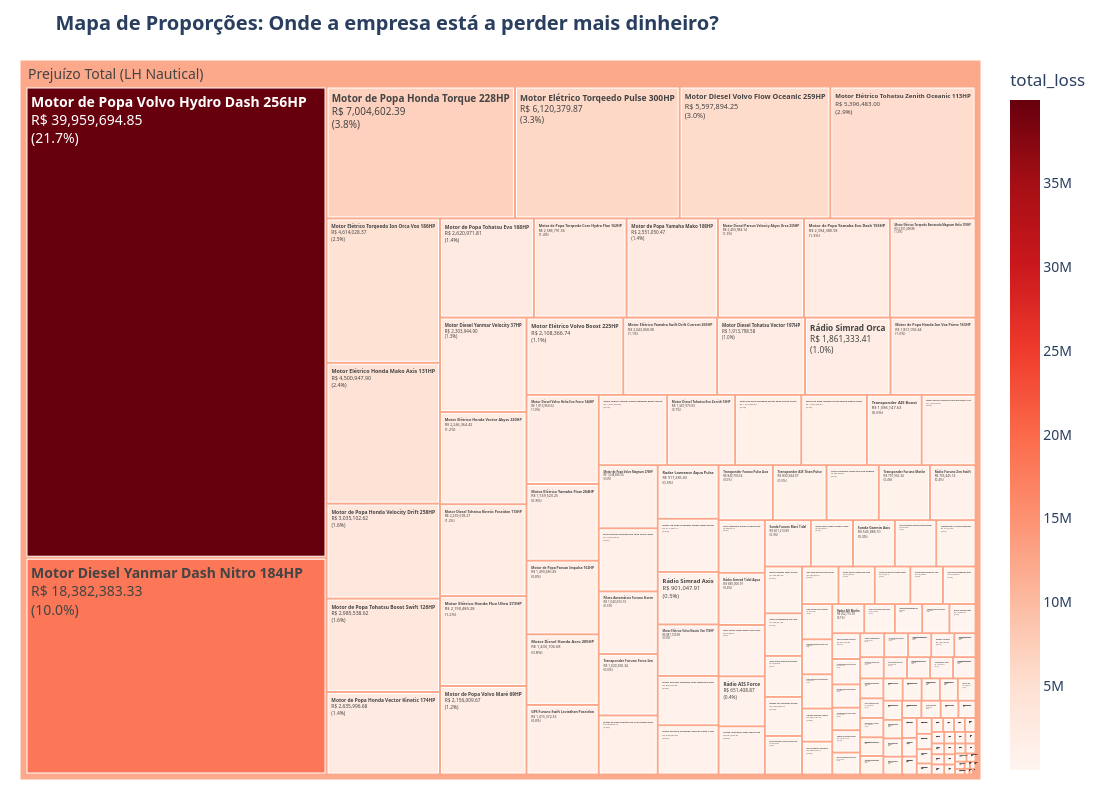

In [10]:
import plotly.express as px

fig = px.treemap(
    df_loss,
    path=[px.Constant("Prejuízo Total (LH Nautical)"), 'name'],
    values='total_loss',
    color='total_loss',
    color_continuous_scale='Reds',
    title='<b>Mapa de Proporções: Onde a empresa está a perder mais dinheiro?</b>'
)

fig.update_traces(
    textinfo="label+value+percent parent", 
    texttemplate="<b>%{label}</b><br>R$ %{value:,.2f}<br>(%{percentParent:.1%})",
    hovertemplate="<b>%{label}</b><br>Prejuízo: R$ %{value:,.2f}<extra></extra>"
)

fig.update_layout(
    width=1400,
    height=800,
    margin=dict(t=60, l=20, r=20, b=20),
    font=dict(size=14),
    template='plotly_white'
)

fig.show()

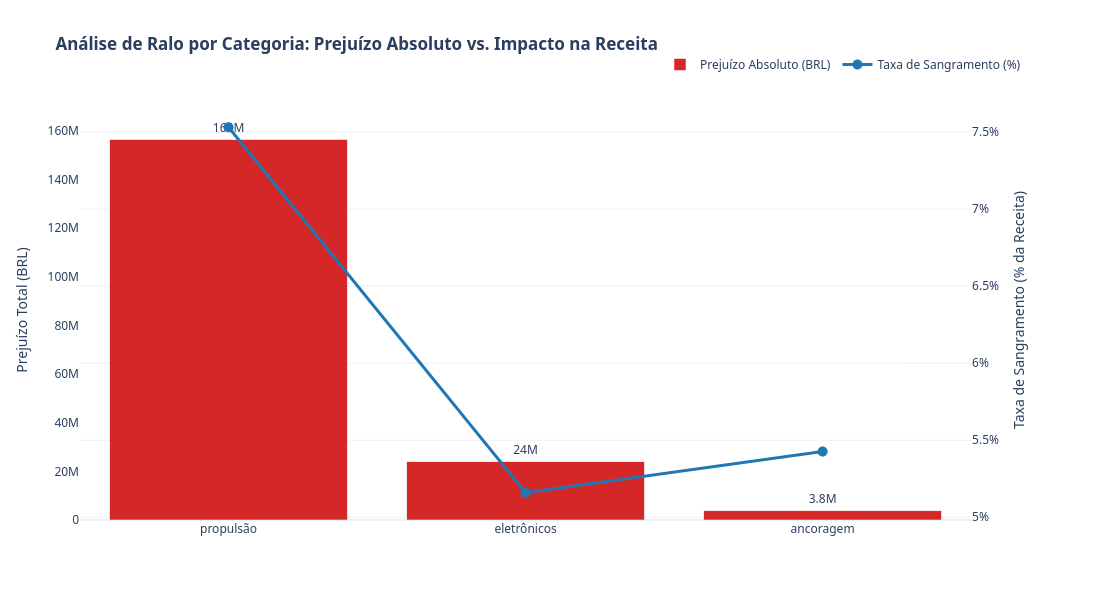

In [15]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df_category = df_report.groupby('actual_category').agg(
    total_revenue=('total_revenue', 'sum'),
    total_loss=('total_loss', 'sum')
).reset_index()

df_category['drain_rate_pct'] = (df_category['total_loss'] / df_category['total_revenue']) * 100

df_category = df_category[df_category['total_loss'] > 0].sort_values(by='total_loss', ascending=False)

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=df_category['actual_category'],
        y=df_category['total_loss'],
        name="Prejuízo Absoluto (BRL)",
        marker_color='#d62728', 
        text=df_category['total_loss'],
        texttemplate='%{text:.2s}',
        textposition='outside'
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=df_category['actual_category'],
        y=df_category['drain_rate_pct'],
        name="Taxa de Sangramento (%)",
        mode='lines+markers',
        line=dict(color='#1f77b4', width=3),
        marker=dict(size=10)
    ),
    secondary_y=True,
)

fig.update_layout(
    title='<b>Análise de Ralo por Categoria: Prejuízo Absoluto vs. Impacto na Receita</b>',
    width=1200,
    height=600,
    template='plotly_white',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="right", x=1),
    margin=dict(t=100)
)

fig.update_yaxes(title_text="Prejuízo Total (BRL)", secondary_y=False, showgrid=False)
fig.update_yaxes(title_text="Taxa de Sangramento (% da Receita)", secondary_y=True, showgrid=True, ticksuffix="%")

fig.show()